# Problema de la Mochila (0-1)

Curso: Investigación de Operaciones  
Estudiante: Kim Seong Kyeong  

---

## Enunciado

Dado un conjunto de **n** objetos, donde cada objeto \(i\) tiene:

- peso \(w_i\)  
- valor \(v_i\)

y una mochila con capacidad máxima \(W\), se desea seleccionar objetos para **maximizar el valor total** sin exceder la capacidad.

---

## Condición (entero y finito)

- Cada objeto se puede elegir **0 o 1 vez**:

$$
x_i \in \{0,1\}
$$

- La cantidad de objetos es **finita**.

---

## Modelo matemático

### Función objetivo

$$
\max Z = \sum_{i=1}^{n} v_i x_i
$$

Maximizar el valor total de los objetos seleccionados.

---

### Restricción de capacidad

$$
\sum_{i=1}^{n} w_i x_i \le W
$$

La suma de los pesos no puede exceder la capacidad de la mochila.

---

### Restricción de integralidad

$$
x_i \in \{0,1\}
$$

Cada objeto puede ser seleccionado **solo una vez o no ser seleccionado**.

## Datos utilizados (ejemplo)

| Objeto | Peso | Valor |
|------|------|------|
| 1 | 2 | 6 |
| 2 | 3 | 10 |
| 3 | 4 | 12 |
| 4 | 5 | 18 |

Capacidad de la mochila:

$$
W = 8
$$

In [2]:
import pandas as pd

# Datos (ejemplo)
pesos = [2, 3, 4, 5]
valores = [6, 10, 12, 18]
W = 8
n = len(pesos)

# DP table
dp = [[0]*(W+1) for _ in range(n+1)]

for i in range(1, n+1):
    wi, vi = pesos[i-1], valores[i-1]
    for w in range(W+1):
        if wi <= w:
            dp[i][w] = max(dp[i-1][w], vi + dp[i-1][w-wi])
        else:
            dp[i][w] = dp[i-1][w]

# Reconstrucción de objetos seleccionados
w = W
seleccionados = []
for i in range(n, 0, -1):
    if dp[i][w] != dp[i-1][w]:
        seleccionados.append(i)  # objetos 1..n
        w -= pesos[i-1]
seleccionados.reverse()

# Tabla de resultados (objetos)
df_objetos = pd.DataFrame({
    "Objeto": list(range(1, n+1)),
    "Peso": pesos,
    "Valor": valores
})
df_objetos["Seleccionado"] = df_objetos["Objeto"].isin(seleccionados).map({True: "Sí", False: "No"})

peso_total = df_objetos.loc[df_objetos["Seleccionado"]=="Sí", "Peso"].sum()
valor_total = df_objetos.loc[df_objetos["Seleccionado"]=="Sí", "Valor"].sum()

# Resumen
df_resumen = pd.DataFrame({
    "Métrica": ["Capacidad (W)", "Peso total", "Valor máximo", "Objetos seleccionados"],
    "Resultado": [W, int(peso_total), int(valor_total), ", ".join(map(str, seleccionados)) if seleccionados else "Ninguno"]
})

print("=== Tabla de objetos ===")
display(df_objetos)

print("=== Resumen ===")
display(df_resumen)

=== Tabla de objetos ===


,Objeto,Peso,Valor,Seleccionado
0,1,2,6,No
1,2,3,10,Sí
2,3,4,12,No
3,4,5,18,Sí


=== Resumen ===


,Métrica,Resultado
0,Capacidad (W),8
1,Peso total,8
2,Valor máximo,28
3,Objetos seleccionados,"2, 4"


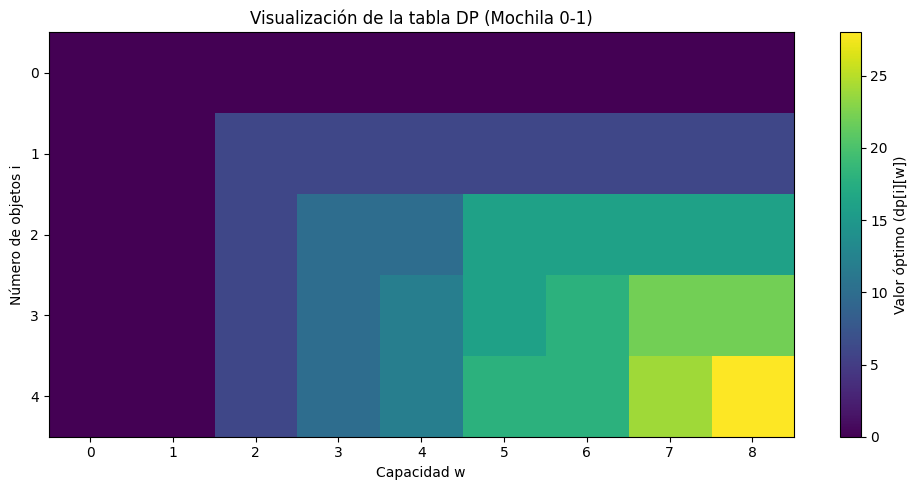

In [3]:
import numpy as np
import matplotlib.pyplot as plt

dp_arr = np.array(dp)

plt.figure(figsize=(10, 5))
plt.imshow(dp_arr, aspect="auto")
plt.colorbar(label="Valor óptimo (dp[i][w])")

plt.title("Visualización de la tabla DP (Mochila 0-1)")
plt.xlabel("Capacidad w")
plt.ylabel("Número de objetos i")

plt.xticks(ticks=range(W+1), labels=[str(w) for w in range(W+1)])
plt.yticks(ticks=range(n+1), labels=[str(i) for i in range(n+1)])

plt.tight_layout()
plt.show()

## Conclusión

Se resolvió el **problema de la mochila 0-1** mediante **programación dinámica**, obteniendo el **valor máximo** sin exceder la capacidad \(W\).  
La programación dinámica es adecuada porque construye soluciones óptimas a partir de subproblemas (mejor valor con los primeros \(i\) objetos y capacidad \(w\)) y garantiza encontrar la solución óptima.

Finalmente, se identificaron los **objetos seleccionados** y se presentaron los resultados en forma de **tabla** y **visualización de la tabla DP**, facilitando la interpretación de la solución.

> Complejidad (opcional): \(O(n \cdot W)\) en tiempo y \(O(n \cdot W)\) en memoria